# Tratamento dos textos pra extração de features

In [7]:
import math
import re
import numpy as np
import pandas as pd
from collections import Counter
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker

# --- RECURSOS NLTK ---
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

spell = SpellChecker()

# --- FUNÇÕES DE EXTRAÇÃO ---
def calcular_burstiness(text):
    sentences = sent_tokenize(str(text))
    if len(sentences) <= 1: return 0.0 
    lengths = [len(word_tokenize(s)) for s in sentences]
    return np.std(lengths)

def proporcao_typos(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words: return 0.0
    misspelled = spell.unknown(words)
    return len(misspelled) / len(words)

def calcular_entropia(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words: return 0.0
    counts = Counter(words)
    total_words = len(words)
    return sum([-(c/total_words) * math.log2(c/total_words) for c in counts.values()])

def calcular_ttr(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words: return 0.0
    return len(set(words)) / len(words)

def avg_word_length(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words: return 0.0
    return sum(len(word) for word in words) / len(words)

def avg_sentence_length(text):
    sentences = sent_tokenize(str(text))
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not sentences: return 0.0
    return len(words) / len(sentences)

LLM_BUZZWORDS = {'furthermore', 'moreover', 'delve', 'tapestry', 'testament', 'pivotal', 'underscore', 'multifaceted', 'crucial', 'consequently'}
def proporcao_buzzwords(text):
    words = re.findall(r'\b[a-zA-Z]+\b', str(text).lower())
    if not words: return 0.0
    return sum(1 for word in words if word in LLM_BUZZWORDS) / len(words)

def proporcao_adjetivos(text):
    tokens = word_tokenize(str(text))
    if not tokens: return 0.0
    pos_tags = nltk.pos_tag(tokens)
    return sum(1 for word, tag in pos_tags if tag.startswith('JJ')) / len(tokens)

def densidade_pontuacao(text):
    text_str = str(text)
    if not text_str: return 0.0
    pontos = text_str.count('!') + text_str.count('?') + text_str.count('...')
    return pontos / len(text_str)

# --- PROCESSAMENTO DO DATASET ---
df = pd.read_csv('../data/dataset.csv').dropna()
print("Extraindo 9 métricas comportamentais...")
df['burstiness'] = df['text'].apply(calcular_burstiness)
df['typo_ratio'] = df['text'].apply(proporcao_typos)
df['entropy'] = df['text'].apply(calcular_entropia)
df['ttr'] = df['text'].apply(calcular_ttr)
df['avg_word_len'] = df['text'].apply(avg_word_length)
df['avg_sent_len'] = df['text'].apply(avg_sentence_length)
df['llm_buzzwords'] = df['text'].apply(proporcao_buzzwords)
df['adj_ratio'] = df['text'].apply(proporcao_adjetivos)
df['human_punct'] = df['text'].apply(densidade_pontuacao)

def construir_tfidf_manual(df, max_vocab=512):
    corpus = df['text'].astype(str).tolist()
    tokenized_corpus = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
    doc_freq = Counter()
    for doc in tokenized_corpus:
        for word in set(doc): doc_freq[word] += 1
    vocabulario = [word for word, _ in doc_freq.most_common(max_vocab)]
    N_docs = len(corpus)
    idf = {word: math.log((1 + N_docs) / (1 + doc_freq[word])) + 1 for word in vocabulario}
    tfidf_matrix = []
    for doc in tokenized_corpus:
        tf_counts = Counter(doc)
        doc_len = len(doc) if len(doc) > 0 else 1
        row_tfidf = [(tf_counts.get(w, 0) / doc_len) * idf[w] for w in vocabulario]
        tfidf_matrix.append(row_tfidf)
    return np.array(tfidf_matrix), vocabulario

print("Gerando TF-IDF manual...")
X_tfidf, vocab = construir_tfidf_manual(df, max_vocab=512)
features_list = ['burstiness', 'typo_ratio', 'entropy', 'ttr', 'avg_word_len', 'avg_sent_len', 'llm_buzzwords', 'adj_ratio', 'human_punct']
X_extra = df[features_list].values

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Luimp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Luimp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


Extraindo 9 métricas comportamentais...
Gerando TF-IDF manual...


# Numpy


--- Treino NumPy Puro ---
Epoch 1/100 | Loss: 1.6059
Epoch 11/100 | Loss: 1.3771
Epoch 21/100 | Loss: 1.1246
Epoch 31/100 | Loss: 1.2159
Epoch 41/100 | Loss: 0.9190
Epoch 51/100 | Loss: 0.8696
Epoch 61/100 | Loss: 0.9127
Epoch 71/100 | Loss: 0.7960
Epoch 81/100 | Loss: 0.7976
Epoch 91/100 | Loss: 0.6802
Epoch 100/100 | Loss: 0.7061

--- Avaliação Final ---
Resultados do Modelo NumPy (521 features):
Teste Accuracy: 47.56%


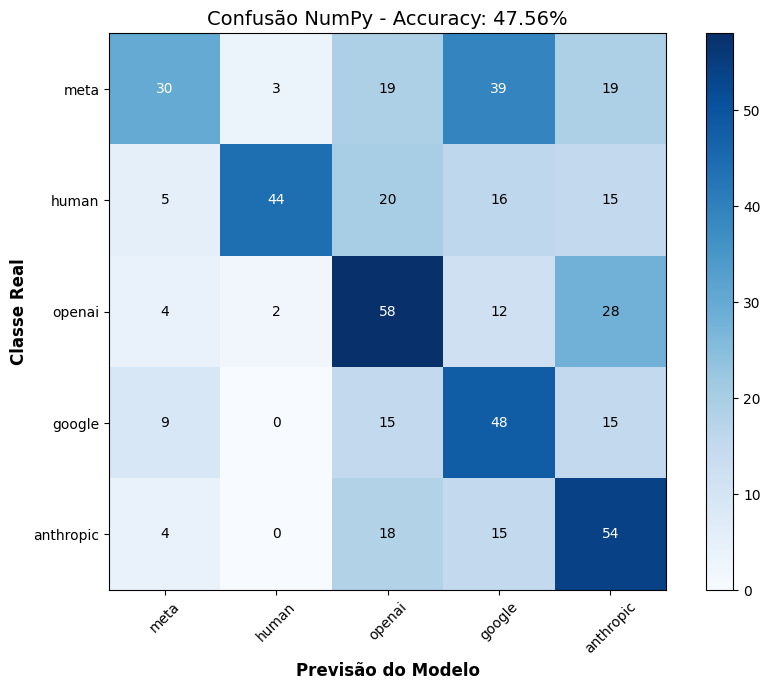

In [8]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
from neuralnet import NeuralNetwork
from layers import DenseLayer
from activations import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy

# 1. Normalização Min-Max Manual
min_vals = np.min(X_extra, axis=0)
max_vals = np.max(X_extra, axis=0)
X_extra_norm = (X_extra - min_vals) / (max_vals - min_vals + 1e-8)

# 2. Concatenar (512 TF-IDF + 9 métricas = 521 inputs)
X_combined_np = np.hstack((X_tfidf, X_extra_norm))

# 3. One-Hot Encoding Manual
labels_np = df['label'].unique()
label_to_idx = {l: i for i, l in enumerate(labels_np)}
Y_indices = np.array([label_to_idx[l] for l in df['label']])
Y_onehot = np.zeros((len(Y_indices), len(labels_np)))
Y_onehot[np.arange(len(Y_indices)), Y_indices] = 1

# 4. Split Manual (70/10/20)
np.random.seed(42)
idx = np.arange(len(X_combined_np)); np.random.shuffle(idx)
X_s, Y_s = X_combined_np[idx], Y_onehot[idx]
train_e, val_e = int(len(X_s)*0.7), int(len(X_s)*0.8)
X_train_np, Y_train_np = X_s[:train_e], Y_s[:train_e]
X_test_np, Y_test_np = X_s[val_e:], Y_s[val_e:]

# 5. Rede Neuronal
nn = NeuralNetwork(loss_func=CategoricalCrossEntropy())
lr, mom = 0.01, 0.9
nn.add(DenseLayer(X_train_np.shape[1], 256, lr, mom))
nn.add(ReLUActivation())
nn.add(DenseLayer(256, 64, lr, mom))
nn.add(ReLUActivation())
nn.add(DenseLayer(64, 32, lr, mom))
nn.add(ReLUActivation())
nn.add(DenseLayer(32, Y_onehot.shape[1], lr, mom))
nn.add(SoftmaxActivation())

print("\n--- Treino NumPy Puro ---")
nn.fit(X_train_np, Y_train_np, epochs=100, batch_size=32, verbose=True)

# 6. Avaliação e Matriz de Confusão Numpy
print("\n--- Avaliação Final ---")

# Obter as probabilidades e converter para classes (índices)
y_pred_proba = nn.forward_propagation(X_test_np)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(Y_test_np, axis=1)

# --- CALCULAR E IMPRIMIR ACCURACY ---
accuracy = np.mean(y_pred == y_true) * 100
print(f"Resultados do Modelo NumPy (521 features):")
print(f"Teste Accuracy: {accuracy:.2f}%")

# --- CRIAR MATRIZ DE CONFUSÃO ---
num_classes = len(labels_np)
cm = np.zeros((num_classes, num_classes), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

# --- DESENHAR MATRIZ COM NÚMEROS ---
plt.figure(figsize=(9, 7))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'Confusão NumPy - Accuracy: {accuracy:.2f}%', fontsize=14)
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, labels_np, rotation=45)
plt.yticks(tick_marks, labels_np)

# Adicionar os números dentro dos quadrados
thresh = cm.max() / 2. # Limiar para mudar a cor do texto (melhor leitura)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Pytorch


--- Treino PyTorch ---
Época 20 concluída.
Época 40 concluída.
Época 60 concluída.
Época 80 concluída.
Época 100 concluída.

PyTorch Accuracy: 51.22%


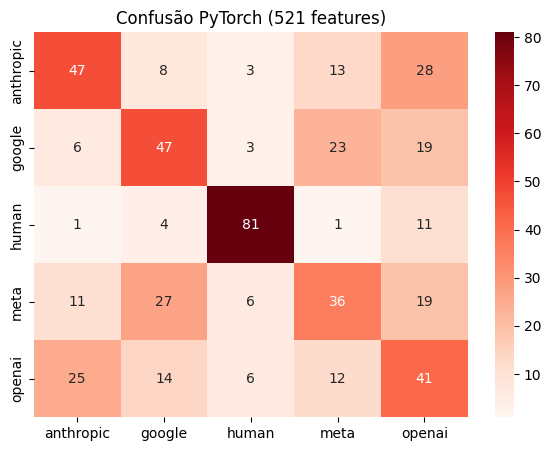

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Preparação Sklearn
scaler = MinMaxScaler()
X_extra_scaled = scaler.fit_transform(X_extra)
X_combined_pt = np.hstack((X_tfidf, X_extra_scaled))

encoder = LabelEncoder()
y_pt = encoder.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(X_combined_pt, y_pt, test_size=0.2, stratify=y_pt, random_state=42)

# 2. Tensores e Loaders
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train).to(device), torch.LongTensor(y_train).to(device)), batch_size=32, shuffle=True)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# 3. Modelo PyTorch
class DetectorIADeep(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    def forward(self, x): return self.net(x)

model = DetectorIADeep(X_train.shape[1], len(encoder.classes_)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

# 4. Treino
print("\n--- Treino PyTorch ---")
for epoch in range(100):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 20 == 0: print(f"Época {epoch+1} concluída.")

# 5. Accuracy e Matriz Seaborn
model.eval()
with torch.no_grad():
    outputs = model(X_test_t)
    _, predicted = torch.max(outputs, 1)
    acc = 100 * (predicted == y_test_t).sum().item() / y_test_t.size(0)

print(f"\nPyTorch Accuracy: {acc:.2f}%")

from sklearn.metrics import confusion_matrix
cm_pt = confusion_matrix(y_test_t.cpu(), predicted.cpu())
plt.figure(figsize=(7, 5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Reds', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('Confusão PyTorch (521 features)')
plt.show()